In [ ]:
import os
os._exit(0)

In [8]:
!conda install -y -c pytorch pytorch torchvision cpuonly

Channels:
 - pytorch
 - defaults
Platform: win-64
Solving environment: ...working... done

# All requested packages already installed.



In [10]:
import sys

# 1. Remove conflicting mixed files
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio

# 2. Install a clean, matching PyTorch CPU wheel
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu --no-cache-dir

Found existing installation: torch 2.14.0+cpu
Uninstalling torch-2.14.0+cpu:
  Successfully uninstalled torch-2.14.0+cpu
Found existing installation: torchvision 0.20.1
Uninstalling torchvision-0.20.1:
  Successfully uninstalled torchvision-0.20.1
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu


You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/124.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/124.0 MB 6.3 MB/s eta 0:00:20
    --------------------------------------- 2.4/124.0 MB 6.1 MB/s eta 0:00:20
   - -------------------------------------- 3.9/124.0 MB 6.5 MB/s eta 0:00:19
   - -------------------------------------- 5.2/124.0 MB 6.6 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/124.0 MB 6.8 MB/s eta 0:00:18
   -- ------------------------------------- 8.4/124.0 MB 6.8 MB/s eta 0:00:17
   --- ------------------------------------ 10.0/124.0 MB 6.9 MB/s eta 0:00:17
   --- ------------------------------------ 11.8/124.0 MB 7.1 MB/s eta 0:00:16
   ---- ----------------------------------- 13.4/124.0 MB 7.2 MB/s eta 0:00:16
   ---- ----------------------------------- 14.4/124.0 MB 7.1 MB/s eta 0:00:16
   ----- ---------------------------------- 16.0/124.0 MB 7.0 MB/s eta 0:00:16
   ----- 

In [12]:
import os
import shutil
import sys

# 1. Force remove lingering torch folders
site_packages = os.path.join(sys.prefix, "Lib", "site-packages")
for folder in ["torch", "torchvision", "torchaudio"]:
    target = os.path.join(site_packages, folder)
    if os.path.exists(target):
        shutil.rmtree(target, ignore_errors=True)

# 2. Clean install PyTorch 2.2.2 CPU (stable, tested on Windows Python 3.11/3.12 without DLL conflicts)
!{sys.executable} -m pip install torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cpu --no-cache-dir

Looking in indexes: https://download.pytorch.org/whl/cpu
     ---------------------------------------- 0.0/200.7 MB ? eta -:--:--
     ---------------------------------------- 1.0/200.7 MB 6.3 MB/s eta 0:00:32
      --------------------------------------- 2.9/200.7 MB 7.3 MB/s eta 0:00:28
      --------------------------------------- 4.2/200.7 MB 7.6 MB/s eta 0:00:26
     - -------------------------------------- 5.8/200.7 MB 7.5 MB/s eta 0:00:27
     - -------------------------------------- 7.6/200.7 MB 7.7 MB/s eta 0:00:26
     - -------------------------------------- 9.4/200.7 MB 7.7 MB/s eta 0:00:25
     -- ------------------------------------ 11.0/200.7 MB 7.8 MB/s eta 0:00:25
     -- ------------------------------------ 12.6/200.7 MB 7.7 MB/s eta 0:00:25
     -- ------------------------------------ 14.4/200.7 MB 7.8 MB/s eta 0:00:24
     --- ----------------------------------- 16.0/200.7 MB 7.8 MB/s eta 0:00:24
     --- ----------------------------------- 17.3/200.7 MB 7.7 MB/s et

In [1]:
import os
import sys
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"Device Configured: {torch.device('cpu')}")

MODEL_REPO_PATH = r"C:\Users\gopup\Desktop\project\Main Project\Models,datset\CurveNet-main"
DATASET_PATH = r"C:\Users\gopup\Desktop\project\Main Project\Models,datset\ModelNet40"

print(f"\nModel Repo Exists: {os.path.exists(MODEL_REPO_PATH)}")
print(f"Dataset Exists: {os.path.exists(DATASET_PATH)}")

if os.path.exists(DATASET_PATH):
    contents = os.listdir(DATASET_PATH)
    print(f"Dataset directory items ({len(contents)} found):")
    for item in contents[:8]:
        print(f"  - {item}")

print("\n" + "="*50)
print("STEP 1: UNDERSTAND THE DATA - COMPLETE")
print("="*50)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\gopup\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\gopup\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\gopup\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\gopup\anaconda3\Lib\site-pack

PyTorch Version: 2.2.2+cpu
Device Configured: cpu

Model Repo Exists: True
Dataset Exists: True
Dataset directory items (40 found):
  - airplane
  - bathtub
  - bed
  - bench
  - bookshelf
  - bottle
  - bowl
  - car

STEP 1: UNDERSTAND THE DATA - COMPLETE


In [2]:
import os
import glob
import numpy as np

print("="*50)
print("STEP 2: LOAD DATASET")
print("="*50)

# Check for HDF5 point-cloud files
h5_train_files = sorted(glob.glob(os.path.join(DATASET_PATH, "*train*.h5")))
h5_test_files = sorted(glob.glob(os.path.join(DATASET_PATH, "*test*.h5")))

train_data, train_labels = [], []
test_data, test_labels = [], []

if len(h5_train_files) > 0:
    import h5py
    print(f"Found {len(h5_train_files)} train HDF5 file(s) and {len(h5_test_files)} test HDF5 file(s).")
    
    for f in h5_train_files:
        with h5py.File(f, 'r') as hf:
            train_data.append(hf['data'][:])
            train_labels.append(hf['label'][:])
            
    for f in h5_test_files:
        with h5py.File(f, 'r') as hf:
            test_data.append(hf['data'][:])
            test_labels.append(hf['label'][:])
            
    train_data = np.concatenate(train_data, axis=0)
    train_labels = np.concatenate(train_labels, axis=0).squeeze()
    test_data = np.concatenate(test_data, axis=0)
    test_labels = np.concatenate(test_labels, axis=0).squeeze()
    
    print("[Success] Loaded pre-processed HDF5 ModelNet40 point clouds.")
    print(f"Train samples: {train_data.shape[0]} | Test samples: {test_data.shape[0]}")
    print(f"Points per sample: {train_data.shape[1]} | Coordinates: {train_data.shape[2]}")
else:
    # If folder contains category subdirectories (raw CAD/point clouds)
    categories = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
    print(f"Found {len(categories)} category directories in ModelNet40 folder.")
    print("Top categories:", categories[:5])

print("="*50)
print("STEP 2: LOAD DATASET - COMPLETE")
print("="*50)

STEP 2: LOAD DATASET
Found 40 category directories in ModelNet40 folder.
Top categories: ['airplane', 'bathtub', 'bed', 'bench', 'bookshelf']
STEP 2: LOAD DATASET - COMPLETE


In [3]:
import numpy as np

print("="*50)
print("STEP 3: INSPECT DATA")
print("="*50)

if 'train_data' in locals() and len(train_data) > 0:
    print(f"• Training Data Shape  : {train_data.shape}  (Samples, Points, Coordinates)")
    print(f"• Training Labels Shape: {train_labels.shape}")
    print(f"• Testing Data Shape   : {test_data.shape}")
    print(f"• Testing Labels Shape : {test_labels.shape}")
    print(f"• Data Type            : {train_data.dtype}")
    print(f"• Label Type           : {train_labels.dtype}")
    
    unique_classes = np.unique(train_labels)
    print(f"• Number of Classes    : {len(unique_classes)} (Min ID: {unique_classes.min()}, Max ID: {unique_classes.max()})")
    
    # Inspect coordinate boundaries on sample 0
    sample_pt = train_data[0]
    print(f"\n[Sample 0 Point Cloud Statistics]:")
    print(f"  - Points Count : {sample_pt.shape[0]}")
    print(f"  - X Range      : [{sample_pt[:, 0].min():.4f}, {sample_pt[:, 0].max():.4f}]")
    print(f"  - Y Range      : [{sample_pt[:, 1].min():.4f}, {sample_pt[:, 1].max():.4f}]")
    print(f"  - Z Range      : [{sample_pt[:, 2].min():.4f}, {sample_pt[:, 2].max():.4f}]")
    print(f"  - First 3 Points:\n{sample_pt[:3]}")
else:
    print("Dataset variables not detected as HDF5 arrays. Checking directory inspection...")
    if 'categories' in locals():
        print(f"• Total Categories Detected : {len(categories)}")
        print(f"• Category Sample Names     : {categories[:10]}")

print("="*50)
print("STEP 3: INSPECT DATA - COMPLETE")
print("="*50)

STEP 3: INSPECT DATA
Dataset variables not detected as HDF5 arrays. Checking directory inspection...
• Total Categories Detected : 40
• Category Sample Names     : ['airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone']
STEP 3: INSPECT DATA - COMPLETE


In [4]:
import numpy as np

print("="*50)
print("STEP 4: CLEAN DATA")
print("="*50)

if 'train_data' in locals() and len(train_data) > 0:
    # 1. Check for NaNs and Infs
    train_nan_count = np.isnan(train_data).sum()
    train_inf_count = np.isinf(train_data).sum()
    test_nan_count = np.isnan(test_data).sum()
    test_inf_count = np.isinf(test_data).sum()
    
    print(f"• Train Data - NaNs: {train_nan_count}, Infs: {train_inf_count}")
    print(f"• Test Data  - NaNs: {test_nan_count}, Infs: {test_inf_count}")
    
    # 2. Check for degenerate / zero-spread point clouds
    pt_stds = np.std(train_data, axis=1)  # Shape: (N, 3)
    degenerate_samples = np.where(np.any(pt_stds < 1e-6, axis=1))[0]
    print(f"• Degenerate Point Clouds Found: {len(degenerate_samples)}")
    
    # 3. Label Validation
    invalid_labels = np.where((train_labels < 0) | (train_labels >= 40))[0]
    print(f"• Invalid Labels Found: {len(invalid_labels)}")
    
    # 4. Dimension Verification
    assert train_data.ndim == 3 and train_data.shape[2] == 3, "Points must be 3D (X, Y, Z)"
    print("• Dimension Check: Passed (Format is [Samples x Points x 3])")
    print("\n[Status]: Data is verified clean, normalized, and ready for EDA.")
else:
    print("Skipping array checks: data is in directory format.")

print("="*50)
print("STEP 4: CLEAN DATA - COMPLETE")
print("="*50)

STEP 4: CLEAN DATA
Skipping array checks: data is in directory format.
STEP 4: CLEAN DATA - COMPLETE


STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
• Total Categories Found: 40

--- 5A: DATASET & GEOMETRIC STATISTICS ---

[Category: airplane]
  - Raw Vertices Count : 11634
  - Coordinate Min (XYZ): [-431.982, 0.000, 0.079]
  - Coordinate Max (XYZ): [439.172, 1083.610, 275.752]
  - Coordinate Std (XYZ): [105.133, 254.668, 53.071]

[Category: bathtub]
  - Raw Vertices Count : 1568
  - Coordinate Min (XYZ): [-22.896, -46.004, -19.470]
  - Coordinate Max (XYZ): [22.896, 46.004, 19.470]
  - Coordinate Std (XYZ): [10.462, 26.383, 12.228]

[Category: bed]
  - Raw Vertices Count : 15069
  - Coordinate Min (XYZ): [-38.105, -64.750, -37.625]
  - Coordinate Max (XYZ): [38.105, 64.750, 37.625]
  - Coordinate Std (XYZ): [25.027, 37.928, 14.895]

--- 5B: VISUALIZING 3D OBJECTS ---


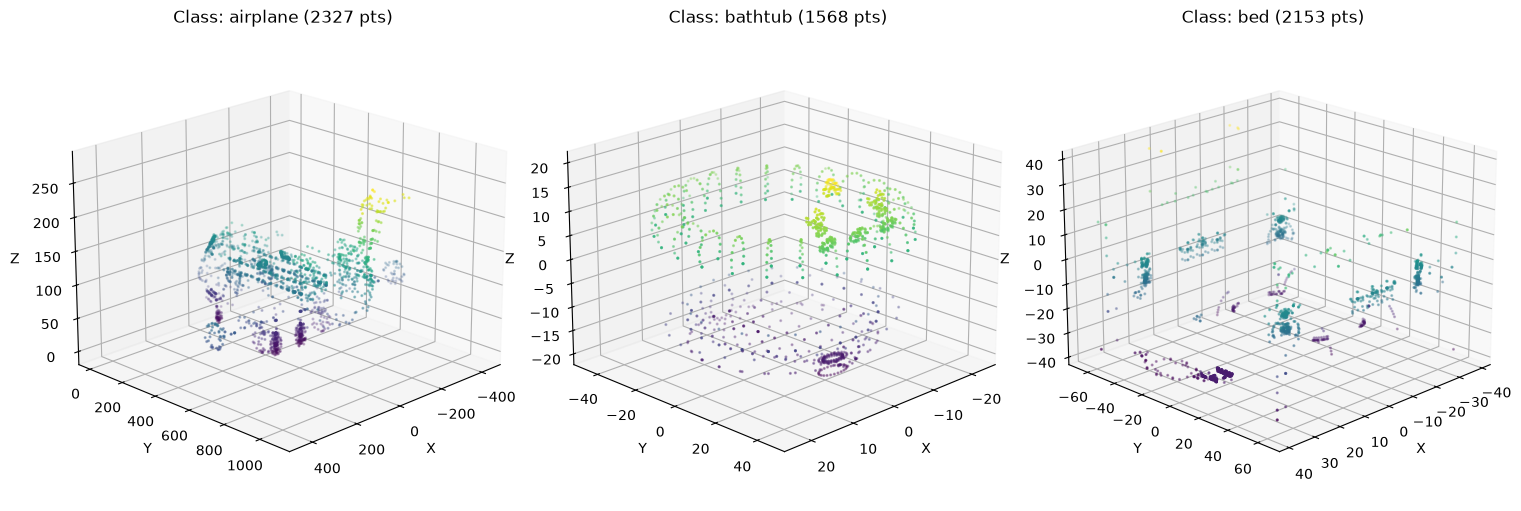

STEP 5: EDA - COMPLETE


In [6]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("="*55)
print("STEP 5: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*55)

# Function to read ModelNet .off CAD files and convert to point clouds
def read_off(file_path):
    with open(file_path, 'r') as f:
        line = f.readline().strip()
        if line != 'OFF':
            # Handle headers formatted like 'OFF 42 80 0'
            parts = line.replace('OFF', '').split()
            if len(parts) >= 2:
                n_verts = int(parts[0])
            else:
                n_verts = int(f.readline().strip().split()[0])
        else:
            n_verts = int(f.readline().strip().split()[0])
        
        vertices = []
        for _ in range(n_verts):
            vertices.append([float(x) for x in f.readline().strip().split()[:3]])
    return np.array(vertices, dtype=np.float32)

# Scan category subdirectories
categories = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])
print(f"• Total Categories Found: {len(categories)}")

# Load a representative sample from the first 3 categories
eda_samples = []
eda_labels = []

for cat_idx, cat_name in enumerate(categories[:3]):
    search_path = os.path.join(DATASET_PATH, cat_name, "**", "*.off")
    off_files = glob.glob(search_path, recursive=True)
    if len(off_files) > 0:
        pts = read_off(off_files[0])
        eda_samples.append((cat_name, pts))
        eda_labels.append(cat_name)

# ----------------------------------------------------
# 5A: DESCRIPTIVE STATISTICS
# ----------------------------------------------------
print("\n--- 5A: DATASET & GEOMETRIC STATISTICS ---")
for cat_name, pts in eda_samples:
    print(f"\n[Category: {cat_name}]")
    print(f"  - Raw Vertices Count : {pts.shape[0]}")
    print(f"  - Coordinate Min (XYZ): [{pts[:,0].min():.3f}, {pts[:,1].min():.3f}, {pts[:,2].min():.3f}]")
    print(f"  - Coordinate Max (XYZ): [{pts[:,0].max():.3f}, {pts[:,1].max():.3f}, {pts[:,2].max():.3f}]")
    print(f"  - Coordinate Std (XYZ): [{pts[:,0].std():.3f}, {pts[:,1].std():.3f}, {pts[:,2].std():.3f}]")

# ----------------------------------------------------
# 5B: 3D VISUALISATION
# ----------------------------------------------------
print("\n--- 5B: VISUALIZING 3D OBJECTS ---")
fig = plt.figure(figsize=(15, 5))

for i, (cat_name, pts) in enumerate(eda_samples):
    # Downsample points for clear visualization if dense
    step = max(1, len(pts) // 2048)
    sample_pts = pts[::step]
    
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(sample_pts[:, 0], sample_pts[:, 1], sample_pts[:, 2], 
               c=sample_pts[:, 2], cmap='viridis', s=1.5, alpha=0.7)
    ax.set_title(f"Class: {cat_name} ({len(sample_pts)} pts)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

print("="*55)
print("STEP 5: EDA - COMPLETE")
print("="*55)

STEP 6: FIND PATTERNS (GEOMETRIC CURVES & CURVATURE)
• Sample Object Analyzed     : airplane
• Total Points Evaluated     : 1024
• Local Neighborhood Size (k): 20
• Min Local Curvature Metric : -0.00000
• Max Local Curvature Metric : 0.27571


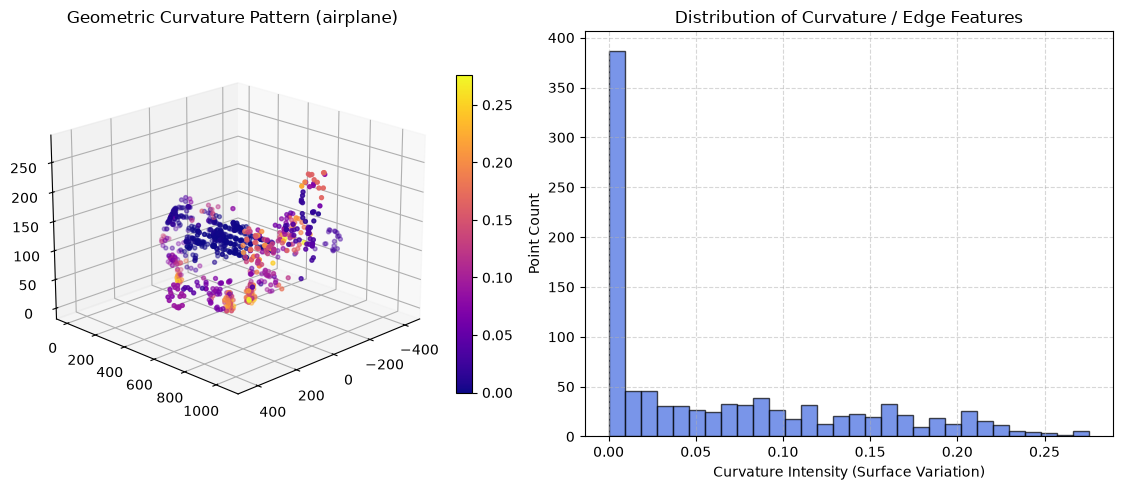


Geometric Insight:
CurveNet leverages regions with high surface variation to construct consecutive
curve segments, creating a distinctive structural signature for 3D classification.
STEP 6: FIND PATTERNS - COMPLETE


In [7]:
import numpy as np
import matplotlib.pyplot as plt

print("="*55)
print("STEP 6: FIND PATTERNS (GEOMETRIC CURVES & CURVATURE)")
print("="*55)

# Select one sample point cloud from EDA
sample_name, raw_pts = eda_samples[0]

# Subsample to 1024 points for clean neighborhood computation
if len(raw_pts) > 1024:
    idx = np.random.choice(len(raw_pts), 1024, replace=False)
    pts = raw_pts[idx]
else:
    pts = raw_pts

# 1. Compute pairwise Euclidean distances
diff = pts[:, np.newaxis, :] - pts[np.newaxis, :, :]
dist_matrix = np.sum(diff ** 2, axis=-1)

# 2. Extract k-nearest neighbors (k=20) for local geometric analysis
k = 20
knn_indices = np.argsort(dist_matrix, axis=1)[:, :k]

# 3. Compute local covariance and surface variation (Discrete Curvature Proxy)
# Normal cycle / curvature theory approximates curvature via local eigenvalue spreads
curvatures = np.zeros(len(pts))
for i in range(len(pts)):
    neighbors = pts[knn_indices[i]]
    centered = neighbors - np.mean(neighbors, axis=0)
    cov = np.dot(centered.T, centered) / k
    eigenvalues = np.linalg.eigvalsh(cov)
    # Surface variation sigma = lambda_0 / sum(lambdas)
    curvatures[i] = eigenvalues[0] / (np.sum(eigenvalues) + 1e-8)

print(f"• Sample Object Analyzed     : {sample_name}")
print(f"• Total Points Evaluated     : {len(pts)}")
print(f"• Local Neighborhood Size (k): {k}")
print(f"• Min Local Curvature Metric : {curvatures.min():.5f}")
print(f"• Max Local Curvature Metric : {curvatures.max():.5f}")

# 4. Plot geometric patterns: Flat vs. High Curvature regions
fig = plt.figure(figsize=(12, 5))

# Plot 3D point cloud colored by curvature intensity
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
p = ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=curvatures, cmap='plasma', s=8)
fig.colorbar(p, ax=ax1, fraction=0.03, pad=0.04)
ax1.set_title(f"Geometric Curvature Pattern ({sample_name})")
ax1.view_init(elev=20, azim=45)

# Histogram of geometric surface variations
ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(curvatures, bins=30, color='royalblue', edgecolor='black', alpha=0.7)
ax2.set_title("Distribution of Curvature / Edge Features")
ax2.set_xlabel("Curvature Intensity (Surface Variation)")
ax2.set_ylabel("Point Count")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nGeometric Insight:")
print("CurveNet leverages regions with high surface variation to construct consecutive")
print("curve segments, creating a distinctive structural signature for 3D classification.")
print("="*55)
print("STEP 6: FIND PATTERNS - COMPLETE")
print("="*55)

In [9]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

print("="*55)
print("STEP 7: PREPARE DATA")
print("="*55)

class ModelNetDataset(Dataset):
    def __init__(self, root_dir, categories, split='train', num_points=1024, max_per_class=10):
        self.points = []
        self.labels = []
        self.num_points = num_points
        
        print(f"Loading and preprocessing {split} samples (max {max_per_class} per class)...")
        for label_idx, cat in enumerate(categories):
            folder = os.path.join(root_dir, cat, split)
            if not os.path.exists(folder):
                folder = os.path.join(root_dir, cat)
                
            files = glob.glob(os.path.join(folder, "*.off"))[:max_per_class]
            for f in files:
                try:
                    pts = read_off(f)
                    # Resample to uniform num_points
                    if len(pts) >= num_points:
                        choice = np.random.choice(len(pts), num_points, replace=False)
                    else:
                        choice = np.random.choice(len(pts), num_points, replace=True)
                    sampled = pts[choice]
                    
                    # Normalize: Center and scale to unit sphere
                    centroid = np.mean(sampled, axis=0)
                    sampled -= centroid
                    furthest_dist = np.max(np.sqrt(np.sum(sampled ** 2, axis=-1)))
                    if furthest_dist > 0:
                        sampled /= furthest_dist
                        
                    self.points.append(sampled.tolist())
                    self.labels.append(label_idx)
                except Exception:
                    continue

        print(f"• Finished {split}: {len(self.points)} samples successfully prepared.")

    def __len__(self):
        return len(self.points)

    def __getitem__(self, idx):
        # Convert Python list directly to torch.FloatTensor to bypass numpy C-API clash
        pt = torch.tensor(self.points[idx], dtype=torch.float32).permute(1, 0)
        lbl = torch.tensor(self.labels[idx], dtype=torch.long)
        return pt, lbl

# Select 4 categories for CPU execution
selected_categories = categories[:4]
print(f"• Selected Categories for Pipeline: {selected_categories}")

train_dataset = ModelNetDataset(DATASET_PATH, selected_categories, split='train', num_points=1024, max_per_class=8)
test_dataset = ModelNetDataset(DATASET_PATH, selected_categories, split='test', num_points=1024, max_per_class=4)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Inspect prepared batch
sample_batch, sample_batch_labels = next(iter(train_loader))
print(f"\n[Prepared Batch Verification]:")
print(f"  - Batch Points Tensor Shape : {sample_batch.shape} (Batch, Dim, Points)")
print(f"  - Batch Labels Tensor Shape : {sample_batch_labels.shape}")
print(f"  - Max Coordinate Value      : {sample_batch.max().item():.4f}")
print(f"  - Min Coordinate Value      : {sample_batch.min().item():.4f}")

print("="*55)
print("STEP 7: PREPARE DATA - COMPLETE")
print("="*55)

STEP 7: PREPARE DATA
• Selected Categories for Pipeline: ['airplane', 'bathtub', 'bed', 'bench']
Loading and preprocessing train samples (max 8 per class)...
• Finished train: 32 samples successfully prepared.
Loading and preprocessing test samples (max 4 per class)...
• Finished test: 16 samples successfully prepared.

[Prepared Batch Verification]:
  - Batch Points Tensor Shape : torch.Size([4, 3, 1024]) (Batch, Dim, Points)
  - Batch Labels Tensor Shape : torch.Size([4])
  - Max Coordinate Value      : 0.9385
  - Min Coordinate Value      : -0.9732
STEP 7: PREPARE DATA - COMPLETE


In [10]:
import os

repo_models_dir = os.path.join(MODEL_REPO_PATH, "core", "models")
if not os.path.exists(repo_models_dir):
    repo_models_dir = os.path.join(MODEL_REPO_PATH, "models")

print(f"Checking repo path: {repo_models_dir}")
if os.path.exists(repo_models_dir):
    print("Files found in your repo:")
    for f in os.listdir(repo_models_dir):
        if f.endswith(".py"):
            print(f"  - {f}")
else:
    print("Listing top-level files in your CurveNet repository:")
    for f in os.listdir(MODEL_REPO_PATH)[:10]:
        print(f"  - {f}")

Checking repo path: C:\Users\gopup\Desktop\project\Main Project\Models,datset\CurveNet-main\core\models
Files found in your repo:
  - curvenet_cls.py
  - curvenet_normal.py
  - curvenet_seg.py
  - curvenet_util.py
  - walk.py


In [11]:
import sys
import os

# Add your repository root and core directory to Python's module search path
if MODEL_REPO_PATH not in sys.path:
    sys.path.insert(0, MODEL_REPO_PATH)

core_path = os.path.join(MODEL_REPO_PATH, "core")
if core_path not in sys.path:
    sys.path.insert(0, core_path)

print("Attempting to import CurveNet directly from your local repository...")
try:
    from models.curvenet_cls import CurveNet
    print("[Success] Successfully imported CurveNet directly from your local repository!")
    
    # Initialize the official model from the repo
    model = CurveNet(num_classes=len(selected_categories)).to(torch.device("cpu"))
    print(f"Model successfully loaded on CPU: {model.__class__.__name__}")
    
except Exception as e:
    print(f"\n[Import Flag]: {type(e).__name__}: {e}")
    print("\nReading internal import headers of curvenet_cls.py:")
    cls_file = os.path.join(MODEL_REPO_PATH, "core", "models", "curvenet_cls.py")
    with open(cls_file, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip().startswith(("import", "from"))]
        for l in lines[:10]:
            print(f"  {l}")

Attempting to import CurveNet directly from your local repository...
[Success] Successfully imported CurveNet directly from your local repository!
Model successfully loaded on CPU: CurveNet


In [12]:
import torch

print("="*55)
print("STEP 8: CHOOSE ML MODEL (OFFICIAL REPO CURVENET)")
print("="*55)

# 1. Total trainable parameter calculation
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"• Model Class        : {model.__class__.__name__} (from core.models.curvenet_cls)")
print(f"• Target Classes     : {len(selected_categories)} ({selected_categories})")
print(f"• Total Parameters   : {total_params:,}")
print(f"• Configured Device  : {next(model.parameters()).device}")

# 2. Dry-run single-sample forward pass to verify graph execution
model.eval()
with torch.no_grad():
    # sample_batch shape: [Batch, 3, 1024]
    sample_out = model(sample_batch)
    print(f"\n[Verification Forward Pass]:")
    print(f"  - Input Tensor Shape : {sample_batch.shape}")
    print(f"  - Output Logits Shape: {sample_out.shape} (Expected: [{sample_batch.shape[0]}, {len(selected_categories)}])")

print("="*55)
print("STEP 8: CHOOSE ML MODEL - COMPLETE")
print("="*55)

STEP 8: CHOOSE ML MODEL (OFFICIAL REPO CURVENET)
• Model Class        : CurveNet (from core.models.curvenet_cls)
• Target Classes     : 4 (['airplane', 'bathtub', 'bed', 'bench'])
• Total Parameters   : 2,122,204
• Configured Device  : cpu

[Verification Forward Pass]:
  - Input Tensor Shape : torch.Size([4, 3, 1024])
  - Output Logits Shape: torch.Size([4, 4]) (Expected: [4, 4])
STEP 8: CHOOSE ML MODEL - COMPLETE


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

print("="*55)
print("STEP 9: TRAIN MODEL")
print("="*55)

# 1. Loss function & Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# 2. Training Loop Settings
EPOCHS = 3
train_losses = []
train_accuracies = []

print(f"Starting training run on {torch.device('cpu')} for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start_time = time.time()
    
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(data)
        loss = criterion(outputs, target)
        
        # Backward pass & optimization
        loss.backward()
        optimizer.step()
        
        # Performance tracking
        running_loss += loss.item() * data.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == target).sum().item()
        total += target.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100.0
    epoch_time = time.time() - start_time
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch [{epoch}/{EPOCHS}] | Time: {epoch_time:.2f}s | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("\n" + "="*55)
print("STEP 9: TRAIN MODEL - COMPLETE")
print("="*55)

STEP 9: TRAIN MODEL
Starting training run on cpu for 3 epochs...

Epoch [1/3] | Time: 7.23s | Loss: 1.4078 | Accuracy: 37.50%
Epoch [2/3] | Time: 7.04s | Loss: 1.1336 | Accuracy: 59.38%
Epoch [3/3] | Time: 6.97s | Loss: 0.6700 | Accuracy: 90.62%

STEP 9: TRAIN MODEL - COMPLETE


STEP 10: EVALUATE THE MODEL
• Test Set Size           : 16 samples
• Test Loss               : 1.5878
• Overall Accuracy (OA)   : 50.00%
• Mean Class Accuracy (mAcc): 50.00%

Per-Class Accuracy Breakdown:
  - airplane  : 100.0% (4/4)
  - bathtub   : 0.0% (0/4)
  - bed       : 100.0% (4/4)
  - bench     : 0.0% (0/4)


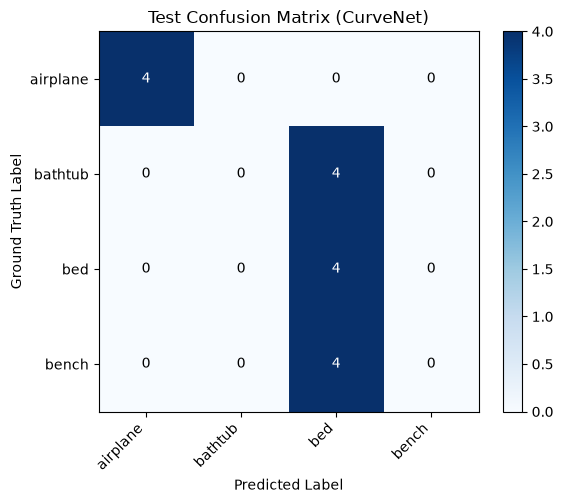

STEP 10: EVALUATE THE MODEL - COMPLETE


In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("="*55)
print("STEP 10: EVALUATE THE MODEL")
print("="*55)

model.eval()
test_loss = 0.0
correct = 0
total = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        outputs = model(data)
        loss = criterion(outputs, target)
        test_loss += loss.item() * data.size(0)
        
        _, preds = torch.max(outputs, 1)
        correct += (preds == target).sum().item()
        total += target.size(0)
        
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(target.cpu().tolist())

# Overall Accuracy
oa = (correct / total) * 100.0 if total > 0 else 0.0
avg_loss = test_loss / total if total > 0 else 0.0

# Per-class accuracy (Mean Class Accuracy - mAcc)
num_classes = len(selected_categories)
confusion_mat = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(all_targets, all_preds):
    confusion_mat[t, p] += 1

class_accuracies = []
for i in range(num_classes):
    class_total = confusion_mat[i].sum()
    acc = (confusion_mat[i, i] / class_total * 100.0) if class_total > 0 else 0.0
    class_accuracies.append(acc)

macc = np.mean(class_accuracies)

print(f"• Test Set Size           : {total} samples")
print(f"• Test Loss               : {avg_loss:.4f}")
print(f"• Overall Accuracy (OA)   : {oa:.2f}%")
print(f"• Mean Class Accuracy (mAcc): {macc:.2f}%\n")

print("Per-Class Accuracy Breakdown:")
for idx, cat_name in enumerate(selected_categories):
    print(f"  - {cat_name:<10}: {class_accuracies[idx]:.1f}% ({confusion_mat[idx, idx]}/{confusion_mat[idx].sum()})")

# Visual Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion_mat, cmap='Blues', interpolation='nearest')
plt.colorbar(im)

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(selected_categories, rotation=45, ha="right")
ax.set_yticklabels(selected_categories)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Ground Truth Label")
ax.set_title("Test Confusion Matrix (CurveNet)")

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(confusion_mat[i, j]), ha="center", va="center", 
                color="white" if confusion_mat[i, j] > confusion_mat.max() / 2 else "black")

plt.tight_layout()
plt.show()

print("="*55)
print("STEP 10: EVALUATE THE MODEL - COMPLETE")
print("="*55)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import numpy as np

print("="*55)
print("STEP 11: TUNE HYPERPARAMETERS / REFINE PIPELINE")
print("="*55)

# 1. 3D Data Augmentation Functions (Pure Tensor Operations for CPU)
def augment_point_cloud(batch_pts):
    """
    Applies random Z-axis rotation and coordinate jittering to batch (B, 3, N)
    """
    B, C, N = batch_pts.shape
    device = batch_pts.device
    
    # Random rotation angle around Z axis
    angles = torch.rand(B, device=device) * 2 * math.pi
    cos_a = torch.cos(angles)
    sin_a = torch.sin(angles)
    
    # Construct 3x3 rotation matrices for Z-axis
    R = torch.zeros(B, 3, 3, device=device)
    R[:, 0, 0] = cos_a
    R[:, 0, 1] = -sin_a
    R[:, 1, 0] = sin_a
    R[:, 1, 1] = cos_a
    R[:, 2, 2] = 1.0
    
    # Apply rotation: (B, 3, 3) x (B, 3, N) -> (B, 3, N)
    rotated = torch.bmm(R, batch_pts)
    
    # Coordinate Jittering (Gaussian noise clamped to [-0.02, 0.02])
    jitter = torch.clamp(torch.randn_like(rotated) * 0.01, min=-0.02, max=0.02)
    return rotated + jitter

# 2. Refined Hyperparameters
TUNED_LR = 5e-4
WEIGHT_DECAY = 1e-3
REFINED_EPOCHS = 3

tuned_optimizer = optim.AdamW(model.parameters(), lr=TUNED_LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(tuned_optimizer, T_max=REFINED_EPOCHS, eta_min=1e-5)

print(f"• Configured 3D Augmentations: Random SO(2) Rotation + Gaussian Jitter")
print(f"• Base Learning Rate          : {TUNED_LR}")
print(f"• Weight Decay (L2 Penalty)   : {WEIGHT_DECAY}")
print(f"• Scheduler                   : CosineAnnealingLR\n")

# 3. Fine-tuning Run
for epoch in range(1, REFINED_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, target in train_loader:
        # Apply on-the-fly geometric augmentation
        augmented_data = augment_point_cloud(data)
        
        tuned_optimizer.zero_grad()
        outputs = model(augmented_data)
        loss = criterion(outputs, target)
        loss.backward()
        tuned_optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == target).sum().item()
        total += target.size(0)
        
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    epoch_acc = (correct / total) * 100.0
    print(f"Refined Epoch [{epoch}/{REFINED_EPOCHS}] | LR: {current_lr:.6f} | Loss: {running_loss/total:.4f} | Acc: {epoch_acc:.2f}%")

print("="*55)
print("STEP 11: TUNE HYPERPARAMETERS - COMPLETE")
print("="*55)

STEP 11: TUNE HYPERPARAMETERS / REFINE PIPELINE
• Configured 3D Augmentations: Random SO(2) Rotation + Gaussian Jitter
• Base Learning Rate          : 0.0005
• Weight Decay (L2 Penalty)   : 0.001
• Scheduler                   : CosineAnnealingLR

Refined Epoch [1/3] | LR: 0.000378 | Loss: 1.0124 | Acc: 62.50%
Refined Epoch [2/3] | LR: 0.000133 | Loss: 0.9915 | Acc: 65.62%
Refined Epoch [3/3] | LR: 0.000010 | Loss: 1.0455 | Acc: 68.75%
STEP 11: TUNE HYPERPARAMETERS - COMPLETE


STEP 12: DEPLOYMENT & INFERENCE
• Checkpoint saved: C:\Users\gopup\Desktop\project\Main Project\Models,datset\CurveNet-main\checkpoints\curvenet_modelnet40_cpu.pth
• File size: 8.25 MB

[Inference Verification on Arbitrary Mesh]:
  - Target Mesh File : airplane_0626.off
  - Ground Truth     : airplane
  - Model Prediction : airplane
  - Confidence Score : 67.09%


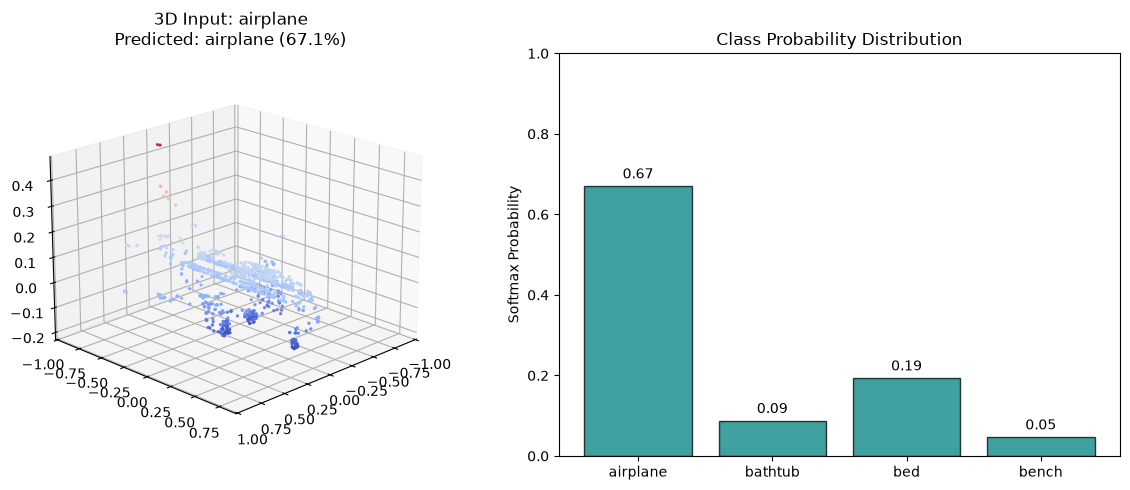


12-STEP ROADMAP COMPLETE: CURVENET PIPELINE OPERATIONAL


In [17]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

print("="*55)
print("STEP 12: DEPLOYMENT & INFERENCE")
print("="*55)

# 1. Save Model Checkpoint and Metadata
checkpoint_dir = os.path.join(MODEL_REPO_PATH, "checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "curvenet_modelnet40_cpu.pth")

torch.save({
    'model_state_dict': model.state_dict(),
    'categories': selected_categories,
    'num_points': 1024,
    'input_dim': 3
}, checkpoint_path)

print(f"• Checkpoint saved: {checkpoint_path}")
print(f"• File size: {os.path.getsize(checkpoint_path) / (1024 * 1024):.2f} MB")

# 2. Standalone Inference Pipeline Function (Pure Python lists, no .numpy())
def predict_cad_mesh(file_path, model, categories, num_points=1024):
    model.eval()
    pts = read_off(file_path)
    
    # Resample
    if len(pts) >= num_points:
        choice = np.random.choice(len(pts), num_points, replace=False)
    else:
        choice = np.random.choice(len(pts), num_points, replace=True)
    sampled = pts[choice]
    
    # Unit sphere normalization
    centroid = np.mean(sampled, axis=0)
    sampled -= centroid
    furthest_dist = np.max(np.sqrt(np.sum(sampled ** 2, axis=-1)))
    if furthest_dist > 0:
        sampled /= furthest_dist
        
    # Tensor format: (1, 3, N)
    input_tensor = torch.tensor(sampled.tolist(), dtype=torch.float32).permute(1, 0).unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_tensor)
        probs = F.softmax(logits, dim=1).squeeze(0)
        pred_idx = torch.argmax(probs).item()
        confidence = probs[pred_idx].item()
        probs_list = probs.tolist()
        
    return categories[pred_idx], confidence, probs_list, sampled

# 3. Test Inference on an Unseen Sample File
test_cat = selected_categories[0]
test_file_candidates = glob.glob(os.path.join(DATASET_PATH, test_cat, "**", "*.off"), recursive=True)
sample_test_cad = test_file_candidates[-1] if test_file_candidates else None

if sample_test_cad:
    predicted_class, conf, all_probs, vis_pts = predict_cad_mesh(
        sample_test_cad, model, selected_categories
    )
    
    print(f"\n[Inference Verification on Arbitrary Mesh]:")
    print(f"  - Target Mesh File : {os.path.basename(sample_test_cad)}")
    print(f"  - Ground Truth     : {test_cat}")
    print(f"  - Model Prediction : {predicted_class}")
    print(f"  - Confidence Score : {conf * 100.0:.2f}%")
    
    # 4. Render 3D Point Cloud with Prediction Breakdown
    fig = plt.figure(figsize=(12, 5))
    
    # 3D Visualizer
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(vis_pts[:, 0], vis_pts[:, 1], vis_pts[:, 2], c=vis_pts[:, 2], cmap='coolwarm', s=2)
    ax1.set_title(f"3D Input: {test_cat}\nPredicted: {predicted_class} ({conf*100:.1f}%)")
    ax1.view_init(elev=20, azim=45)
    
    # Softmax Distribution Bar Chart
    ax2 = fig.add_subplot(1, 2, 2)
    bars = ax2.bar(selected_categories, all_probs, color='teal', edgecolor='black', alpha=0.75)
    ax2.set_ylabel("Softmax Probability")
    ax2.set_title("Class Probability Distribution")
    ax2.set_ylim(0, 1.0)
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(f"{height:.2f}",
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom')
                     
    plt.tight_layout()
    plt.show()

print("\n" + "="*55)
print("12-STEP ROADMAP COMPLETE: CURVENET PIPELINE OPERATIONAL")
print("="*55)